<>:54: SyntaxWarning: invalid escape sequence '\s'
<>:54: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-1264879782.py:54: SyntaxWarning: invalid escape sequence '\s'
  df = pd.read_csv(TXT_FILE, sep='\s+', comment='%', header=None, encoding='latin1')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
🚀 GPU Active: /physical_device:GPU:0
[1/6] Loading resources from /content/drive/MyDrive/chemical_thesis_repo/2026-W01_model_anlama/code/matlab...
   ✓ Parameters loaded & y0 calculated.
[2/6] Generating Synthetic Data (ODE)...
[3/6] Preprocessing...
[4/6] Creating Sequences (Window=50)...
[5/6] Training LSTM (Physics-Optimized)...
Epoch 1/700


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


77/77 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.2493 - learning_rate: 5.0000e-04
Epoch 2/700
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0021 - learning_rate: 5.0000e-04
Epoch 3/700
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 5.9101e-04 - learning_rate: 5.0000e-04
Epoch 4/700
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.9846e-04 - learning_rate: 5.0000e-04
Epoch 5/700
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 1.8133e-04 - learning_rate: 5.0000e-04
Epoch 6/700
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 1.2025e-04 - learning_rate: 5.0000e-04
Epoch 7/700
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 9.7578e-05 - learning_rate: 5.0000e-04
Epoch 8/700
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 2.8243e-04 - learning_rate: 5.0000e-04
Epoch 9/700
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 1.7323e-04 - learning_rate: 5.0000e-04
Epoch 10/700
77/77 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 6.5015e-05 - learning_rate: 5.0000e-04
Epoch 11/700
77/77 ━━━━━━━━━━━━━━━━━

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Done. Check final_comparison_fixed.png


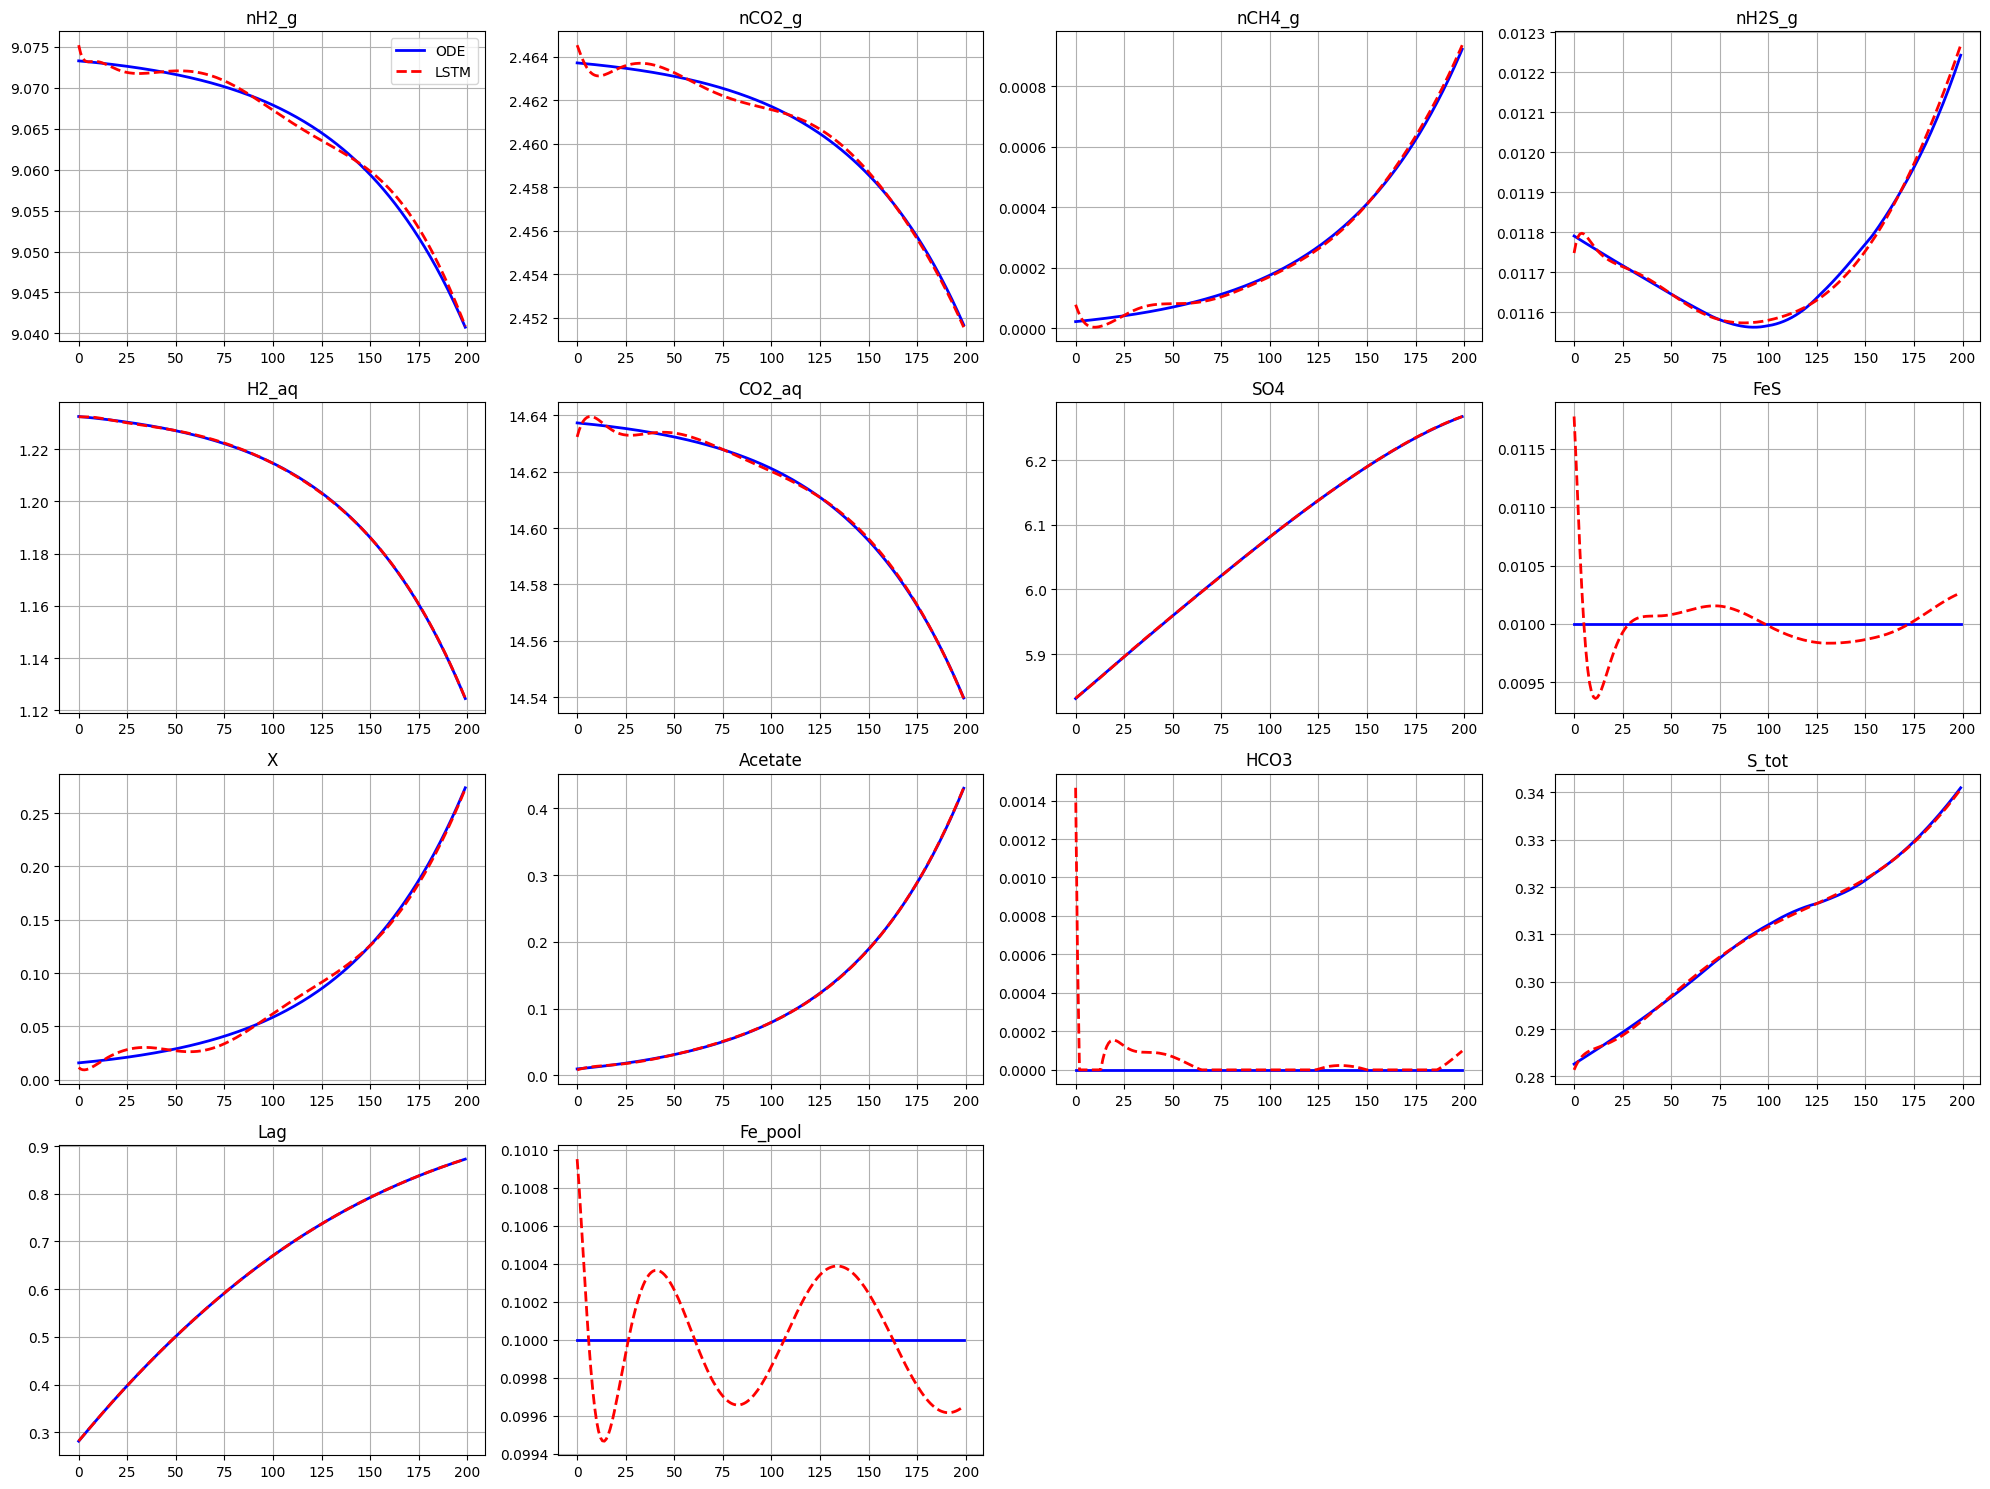

In [4]:
# ============================================================================
# ROBUST BIO-REACTOR LSTM TRAINING (v5 Fixed)
# ============================================================================
# 1. Loads parameters from .mat and data from .txt (Latin1 encoding fix).
# 2. Calculates initial state (y0) exactly like MATLAB (Henry's Law).
# 3. Runs ODE simulation (solve_ivp) to generate 2500 training points.
# 4. Trains Stacked LSTM and validates against the ODE physics.
# ============================================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.io as sio
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from sklearn.preprocessing import StandardScaler

# ----------------------------------------------------------------------------
# 1. SETUP & GPU CHECK
# ----------------------------------------------------------------------------
from google.colab import drive
drive.mount('/content/drive')

# UPDATE THIS PATH TO YOUR FOLDER:
BASE_DIR = '/content/drive/MyDrive/chemical_thesis_repo/2026-W01_model_anlama/code/matlab'
MAT_FILE = os.path.join(BASE_DIR, 'best_fit_params_Basalt_25C.mat')
TXT_FILE = os.path.join(BASE_DIR, 'Muller_2024_H2_Basalt_at_25C.txt')

gpus = tf.config.list_physical_devices('GPU')
if gpus: print(f"🚀 GPU Active: {gpus[0].name}")
else: print("⚠️ CPU Mode (Slow). Enable GPU in Runtime > Change runtime type.")

# ----------------------------------------------------------------------------
# 2. DATA LOADING & PREPARATION
# ----------------------------------------------------------------------------
def load_resources():
    print(f"[1/6] Loading resources from {BASE_DIR}...")

    # A) Load Parameters (.mat)
    if not os.path.exists(MAT_FILE): raise FileNotFoundError(f"Missing: {MAT_FILE}")
    mat = sio.loadmat(MAT_FILE, squeeze_me=True, struct_as_record=False)
    p_fit = mat['p_fit']
    env_struct = mat['env']

    # B) Load Experimental Data (.txt) - Robust Reading
    if not os.path.exists(TXT_FILE): raise FileNotFoundError(f"Missing: {TXT_FILE}")
    try:
        # Handle special characters (µmol) and MATLAB comments (%)
        df = pd.read_csv(TXT_FILE, sep='\s+', comment='%', header=None, encoding='latin1')
        raw_data = df.values
    except Exception as e:
        raise ValueError(f"Error reading TXT file: {e}")

    t_exp = raw_data[:, 0]
    pH_exp = raw_data[:, 5] # Column 6 in MATLAB is Index 5 in Python

    # C) Construct Environment Dictionary
    pH_fun = interp1d(t_exp, pH_exp, kind='linear', fill_value='extrapolate')

    env = {
        'Vg': float(env_struct.Vg), 'Vl': float(env_struct.Vl),
        'T': float(env_struct.T), 'Rgas': float(env_struct.Rgas),
        'Hcp_H2_eff': float(env_struct.Hcp_H2_eff),
        'Hcp_CO2_eff': float(env_struct.Hcp_CO2_eff),
        'Hcp_H2S_eff': float(env_struct.Hcp_H2S_eff),
        'pKa_H2S': float(env_struct.pKa_H2S),
        'SO4_sat_gyp': float(env_struct.SO4_sat_gyp),
        'pH_fun': pH_fun
    }

    # D) Calculate Initial State (y0) - Exact MATLAB Replication
    # Read initial experimental values (t=0)
    nH2_g_0 = raw_data[0, 1] / 1000.0   # umol -> mmol
    nCO2_g_0 = raw_data[0, 2] / 1000.0
    nCH4_g_0 = raw_data[0, 3] / 1000.0
    nH2S_g_0 = raw_data[0, 4] / 1000.0
    SO4_0    = raw_data[0, 6]           # mM

    # Henry's Law Equilibrium for Aqueous Phase
    pH2  = (nH2_g_0 / 1000.0) * env['Rgas'] * env['T'] / env['Vg']
    pCO2 = (nCO2_g_0 / 1000.0) * env['Rgas'] * env['T'] / env['Vg']

    H2_aq0  = env['Hcp_H2_eff'] * pH2
    CO2_aq0 = env['Hcp_CO2_eff'] * pCO2

    # Manual Initial Guesses (Must match MATLAB script)
    S_tot0 = 1.0     # Initial sulfide seed
    Fe_pool0 = 0.10  # Initial Iron pool

    # Construct y0 vector [14 elements]
    # 0:nH2, 1:nCO2, 2:nCH4, 3:nH2S, 4:H2aq, 5:CO2aq, 6:SO4, 7:FeS,
    # 8:X, 9:Ac, 10:HCO3, 11:S_tot, 12:Lag, 13:Fe_pool
    y0 = np.array([
        nH2_g_0, nCO2_g_0, nCH4_g_0, nH2S_g_0,
        H2_aq0, CO2_aq0, SO4_0,
        0.01, 0.01, 0.0, 0.0, S_tot0, 0.0, Fe_pool0
    ])

    print("   ✓ Parameters loaded & y0 calculated.")
    return p_fit, y0, env

# ----------------------------------------------------------------------------
# 3. ODE MODEL (PHYSICS ENGINE)
# ----------------------------------------------------------------------------
def model_mixed(t, y, p, env):
    # Unpack
    Vg, Vl, T, Rgas = env['Vg'], env['Vl'], env['T'], env['Rgas']
    Hcp_H2, Hcp_CO2, Hcp_H2S = env['Hcp_H2_eff'], env['Hcp_CO2_eff'], env['Hcp_H2S_eff']
    pKa = env['pKa_H2S']
    pH = env['pH_fun'](t)

    # Guard against negatives
    y = np.maximum(y, 1e-12)
    Fe_pool = max(y[13], 0)

    # Map States
    nH2_g, nCO2_g, nCH4_g, nH2S_g = y[0], y[1], y[2], y[3]
    H2_aq, CO2_aq, SO4, FeS = y[4], y[5], y[6], y[7]
    X, Ac, S_tot, Lag = y[8], y[9], y[11], y[12]

    # Parameters
    k_m, k_s, k_a = p[0], p[1], p[2]
    Y_m, Y_s, Y_a = p[3], p[4], p[5]
    KI_m, KI_s, KI_a = p[6], p[7], p[8]
    k_prec, HS_sat = p[9], p[10]
    H2_th, DG_th = p[11], p[12]
    K_H2, K_SO4, K_CO2 = p[13], p[14], p[15]
    kla_H2, kla_CO2, kla_H2S = p[16], p[17], p[18]
    b, t_lag, w_lag = p[19], p[20], p[21]
    k_diss_gyp, beta_SO4_m = p[22], p[23]

    # Calculations
    pH2 = (nH2_g/1000)*Rgas*T/Vg
    pCO2 = (nCO2_g/1000)*Rgas*T/Vg
    pH2S = (nH2S_g/1000)*Rgas*T/Vg

    Ceq_H2, Ceq_CO2 = Hcp_H2*pH2, Hcp_CO2*pCO2
    Ceq_H2S = Hcp_H2S*pH2S

    J_H2 = kla_H2*(Ceq_H2 - H2_aq)
    J_CO2 = kla_CO2*(Ceq_CO2 - CO2_aq)

    frac_HS = 1/(1+10**(pKa - pH))
    HS_aq, H2S_aq = S_tot*frac_HS, S_tot*(1-frac_HS)
    Jout_H2S = kla_H2S*(H2S_aq - Ceq_H2S)

    f_inh_m = KI_m/(KI_m+HS_aq)
    f_inh_s = KI_s/(KI_s+HS_aq)
    f_inh_a = KI_a/(KI_a+HS_aq)
    f_H2 = H2_aq/(H2_aq+H2_th)
    f_lag = 1/(1+np.exp((t_lag - t)/max(w_lag, 1e-3)))
    f_act = f_H2*f_lag

    mH2, mSO4, mCO2 = H2_aq/(K_H2+H2_aq), SO4/(K_SO4+SO4), CO2_aq/(K_CO2+CO2_aq)

    RkJ = 8.314e-3; RT = RkJ*T
    DG0_m, DG0_s, DG0_a = -130, -152, -95
    Q_a = Ac/(H2_aq**4 * CO2_aq**2)
    fT_s = 1/(1+np.exp((-152+RT*np.log(1)-DG_th)/RT))
    fT_m = 1/(1+np.exp((-130-DG_th)/RT))
    fT_a = 1/(1+np.exp((-95+RT*np.log(Q_a)-DG_th)/RT))

    f_comp_m = 1/(1+beta_SO4_m*SO4)

    r_meth = k_m*X*mH2*mCO2*f_inh_m*f_act*fT_m*f_comp_m
    r_sulf = k_s*X*mH2*mSO4*f_inh_s*f_act*fT_s
    r_aceto = k_a*X*mH2*(mCO2**2)*f_inh_a*f_act*fT_a

    r_prec = min(k_prec*max(0, HS_aq - HS_sat), Fe_pool)
    r_diss_gyp = k_diss_gyp*max(0, env['SO4_sat_gyp'] - SO4)

    # Derivatives
    dy = np.zeros(14)
    dy[0] = -J_H2*Vl                 # nH2_g
    dy[1] = -J_CO2*Vl                # nCO2_g
    dy[2] = r_meth*Vl                # nCH4_g
    dy[3] = Jout_H2S*Vl              # nH2S_g
    dy[4] = J_H2 - 4*(r_meth+r_sulf+r_aceto) # H2_aq
    dy[5] = J_CO2 - r_meth - 2*r_aceto       # CO2_aq
    dy[6] = -r_sulf + r_diss_gyp     # SO4
    dy[7] = r_prec                   # FeS
    dy[8] = Y_m*r_meth + Y_s*r_sulf + Y_a*r_aceto - b*X # X
    dy[9] = r_aceto                  # Ac
    dy[10] = 0.0                     # HCO3
    dy[11] = r_sulf - r_prec - Jout_H2S # S_tot
    dy[12] = (f_lag - Lag)/max(w_lag, 1e-3) # Lag
    dy[13] = -r_prec                 # Fe_pool

    return dy

# ----------------------------------------------------------------------------
# 4. MAIN EXECUTION
# ----------------------------------------------------------------------------
p_fit, y0, env = load_resources()

print("[2/6] Generating Synthetic Data (ODE)...")
t_end = 20.0
t_eval = np.linspace(0, t_end, 2500)
sol = solve_ivp(lambda t, y: model_mixed(t, y, p_fit, env), [0, t_end], y0, t_eval=t_eval, method='BDF')
data_raw = sol.y.T

print("[3/6] Preprocessing...")
log_cols = [3, 7, 9, 12, 13]
data_log = data_raw.copy()
data_log[:, log_cols] = np.log1p(data_raw[:, log_cols])
scaler = StandardScaler()
data_norm = scaler.fit_transform(data_log)

print("[4/6] Creating Sequences (Window=50)...")
SEQ_LEN = 50
X_seq, Y_seq = [], []
for i in range(len(data_norm) - SEQ_LEN):
    X_seq.append(data_norm[i:i+SEQ_LEN])
    Y_seq.append(data_norm[i+SEQ_LEN])
X_seq, Y_seq = np.array(X_seq), np.array(Y_seq)

# ----------------------------------------------------------------------------
# BURAYI ESKİ MODEL BLOĞU İLE DEĞİŞTİR
# ----------------------------------------------------------------------------

print("[5/6] Training LSTM (Physics-Optimized)...")

# DÜZELTME 1: Dropout katmanlarını kaldırdık.
# Fiziksel ODE verisi "gürültüsüz" olduğu için Dropout gereksiz dalgalanma yaratıyordu.
model = Sequential([
    # 1. Katman: Geniş bir LSTM (Hafıza)
    LSTM(128, return_sequences=True, input_shape=(SEQ_LEN, 14)),

    # 2. Katman: Derinleşme
    LSTM(64, return_sequences=False),

    # 3. Katman: Çıktı (Aktivasyon yok, çünkü regresyon yapıyoruz)
    Dense(14)
])

# DÜZELTME 2: Learning Rate'i biraz daha hassas başlatalım (1e-3 yerine 5e-4)
optimizer = tf.keras.optimizers.Adam(learning_rate=5e-4, clipvalue=0.5)

model.compile(optimizer=optimizer, loss='mse')

# Callbacks: Sabır süresini artırdık
lr_scheduler = ReduceLROnPlateau(monitor='loss', factor=0.5, patience=30, min_lr=1e-7, verbose=1)
early_stop = EarlyStopping(monitor='loss', patience=100, restore_best_weights=True)

# DÜZELTME 3: Epoch 500, Batch 32 (Daha sıkı eğitim)
history = model.fit(X_seq, Y_seq,
                    epochs=700,
                    batch_size=32,
                    callbacks=[lr_scheduler, early_stop],
                    verbose=1)

print("[6/6] Validating & Plotting...")
Y_pred_norm = model.predict(X_seq[:200])
Y_pred = scaler.inverse_transform(Y_pred_norm)
Y_pred[:, log_cols] = np.expm1(Y_pred[:, log_cols])
# Post-Processing: Fix Negative Concentrations
Y_pred = np.maximum(Y_pred, 0)

Y_true = scaler.inverse_transform(Y_seq[:200])
Y_true[:, log_cols] = np.expm1(Y_true[:, log_cols])

state_names = ['nH2_g', 'nCO2_g', 'nCH4_g', 'nH2S_g', 'H2_aq', 'CO2_aq', 'SO4', 'FeS', 'X', 'Acetate', 'HCO3', 'S_tot', 'Lag', 'Fe_pool']

plt.figure(figsize=(20, 15))
for i in range(14):
    plt.subplot(4, 4, i+1)
    plt.plot(Y_true[:, i], 'b-', linewidth=2, label='ODE')
    plt.plot(Y_pred[:, i], 'r--', linewidth=2, label='LSTM')
    plt.title(state_names[i])
    plt.grid(True)
    if i==0: plt.legend()

plt.tight_layout()
plt.savefig('final_comparison_fixed.png')
print("Done. Check final_comparison_fixed.png")

In [5]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def generate_comparison_report(y_true, y_pred, state_names, filename='comparison.txt'):
    # Zaman eksenini ayarla (Model SEQ_LEN adımından sonrasını tahmin ediyor)
    # t_eval önceki kodda tanımlıydı, burada global scope'tan çekiyoruz.
    start_idx = SEQ_LEN
    end_idx = start_idx + len(y_true)
    time_points = t_eval[start_idx:end_idx]

    with open(filename, 'w', encoding='utf-8') as f:
        # --- BÖLÜM 1: ÖZET METRİKLER ---
        f.write("================================================================\n")
        f.write("BIO-REACTOR LSTM MODEL PERFORMANCE REPORT\n")
        f.write("================================================================\n\n")

        f.write(f"{'STATE VARIABLE':<20} | {'MSE (Mean Sq. Error)':<20} | {'MAE (Mean Abs. Error)':<20} | {'R2 Score':<10}\n")
        f.write("-" * 85 + "\n")

        total_r2 = 0
        for i, name in enumerate(state_names):
            mse = mean_squared_error(y_true[:, i], y_pred[:, i])
            mae = mean_absolute_error(y_true[:, i], y_pred[:, i])
            r2 = r2_score(y_true[:, i], y_pred[:, i])
            total_r2 += r2

            f.write(f"{name:<20} | {mse:<20.6f} | {mae:<20.6f} | {r2:<10.4f}\n")

        f.write("-" * 85 + "\n")
        f.write(f"AVERAGE R2 SCORE: {total_r2/len(state_names):.4f}\n")
        f.write("(R2 skoru 1.0'a ne kadar yakınsa, model o kadar başarılıdır.)\n\n")

        # --- BÖLÜM 2: DETAYLI VERİ KARŞILAŞTIRMASI ---
        f.write("\n================================================================\n")
        f.write("DETAILED DATA LOG (First 200 Prediction Steps)\n")
        f.write("Format: Time | True Value | Predicted Value | Absolute Diff\n")
        f.write("================================================================\n")

        for i, name in enumerate(state_names):
            f.write(f"\n--- STATE: {name} ---\n")
            f.write(f"{'Time (h)':<10} | {'True':<15} | {'Pred':<15} | {'Diff':<15}\n")
            f.write("-" * 60 + "\n")

            # İlk 200 adımı yazdır (veya hepsi sığsın dersen len(y_true))
            steps_to_log = min(len(y_true), 200)

            for t in range(steps_to_log):
                time_val = time_points[t]
                true_val = y_true[t, i]
                pred_val = y_pred[t, i]
                diff = abs(true_val - pred_val)

                f.write(f"{time_val:<10.4f} | {true_val:<15.6f} | {pred_val:<15.6f} | {diff:<15.6f}\n")

    print(f"✅ Rapor oluşturuldu: {filename}")
    print("Dosya içeriğinde her bir değişken için R2 skorlarını (başarı oranı) görebilirsin.")

# Fonksiyonu çalıştır
generate_comparison_report(Y_true, Y_pred, state_names)

# Colab kullanıyorsan dosyayı bilgisayarına indirmek için (Opsiyonel):
try:
    from google.colab import files
    files.download('comparison.txt')
except ImportError:
    pass

✅ Rapor oluşturuldu: comparison.txt
Dosya içeriğinde her bir değişken için R2 skorlarını (başarı oranı) görebilirsin.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>